In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional,GRU, Dense, Dropout

In [2]:
df = pd.read_csv("Dataset.csv", sep=",")
print(df.shape)
df.head()


(1048575, 44)


,S.No.,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [3]:
print(df.columns)
print(df['SepsisLabel'].value_counts())

Index(['S.No.', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
       'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='object')
0    1027767
1      20808
Name: SepsisLabel, dtype: int64


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1048575, 44)
Columns: ['S.No.', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,S.No.,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [5]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Identify feature columns
feature_cols = [col for col in df.columns if col not in ["SepsisLabel", "Patient_ID"]]

# Forward-fill within each patient, then replace remaining NaN with 0
df = (
    df.sort_values(["Patient_ID", "Hour"])
      .groupby("Patient_ID", group_keys=False)[feature_cols]
      .ffill()
      .fillna(0)
)

# Add back patient_id + label
df["Patient_ID"] = pd.read_csv("Dataset.csv")["Patient_ID"]
df["SepsisLabel"] = pd.read_csv("Dataset.csv")["SepsisLabel"]

# ==========================
# STEP 4: Normalize features
# ==========================
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ==========================
# STEP 5: Create sequences per patient
# ==========================
def create_sequences(patient_df, seq_len=12):
    sequences, labels = [], []
    features = patient_df[feature_cols].values
    targets = patient_df["SepsisLabel"].values
    
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i+seq_len])
        labels.append(targets[i+seq_len])
    return np.array(sequences), np.array(labels)

X_seq, y_seq = [], []
for pid, group in df.groupby("Patient_ID"):
    seqs, lbls = create_sequences(group, seq_len=12)  # 12-hour window
    if len(seqs) > 0:
        X_seq.append(seqs)
        y_seq.append(lbls)

X_seq = np.vstack(X_seq)
y_seq = np.hstack(y_seq)

print("Final X shape:", X_seq.shape)  # (samples, timesteps, features)
print("Final y shape:", y_seq.shape)  # (samples,)

# ==========================
# STEP 6: Train/Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# ==========================
# STEP 7: Build GRU Model
# ==========================
model = Sequential([
    Bidirectional(GRU(64, return_sequences=True), 
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Bidirectional(GRU(32)),   # returns last output by default
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC()])
model.summary()

# ==========================
# STEP 8: Train Model
# ==========================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

# ==========================
# STEP 9: Evaluate
# ==========================
loss, acc, auc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")


Final X shape: (725054, 12, 42)
Final y shape: (725054,)


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,641 (283.75 KB)

 Trainable params: 72,641 (283.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 168s 23ms/step - accuracy: 0.9745 - auc: 0.7786 - loss: 0.0995 - val_accuracy: 0.9782 - val_auc: 0.8498 - val_loss: 0.0834
Epoch 2/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 152s 21ms/step - accuracy: 0.9788 - auc: 0.8539 - loss: 0.0805 - val_accuracy: 0.9788 - val_auc: 0.8873 - val_loss: 0.0740
Epoch 3/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 123s 17ms/step - accuracy: 0.9798 - auc: 0.9033 - loss: 0.0690 - val_accuracy: 0.9812 - val_auc: 0.9181 - val_loss: 0.0629
Epoch 4/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - accuracy: 0.9820 - auc: 0.9351 - loss: 0.0582 - val_accuracy: 0.9821 - val_auc: 0.9366 - val_loss: 0.0561
Epoch 5/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 102s 14ms/step - accuracy: 0.9835 - auc: 0.9528 - loss: 0.0508 - val_accuracy: 0.9844 - val_auc: 0.9478 - val_loss: 0.0484
Epoch 6/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step - accuracy: 0.9850 - auc: 0.9621 - loss: 0.0443 - val_accuracy: 0.9850 - val_auc: 0.9588 - val_loss: 0.0448
Epoch 7/10
7

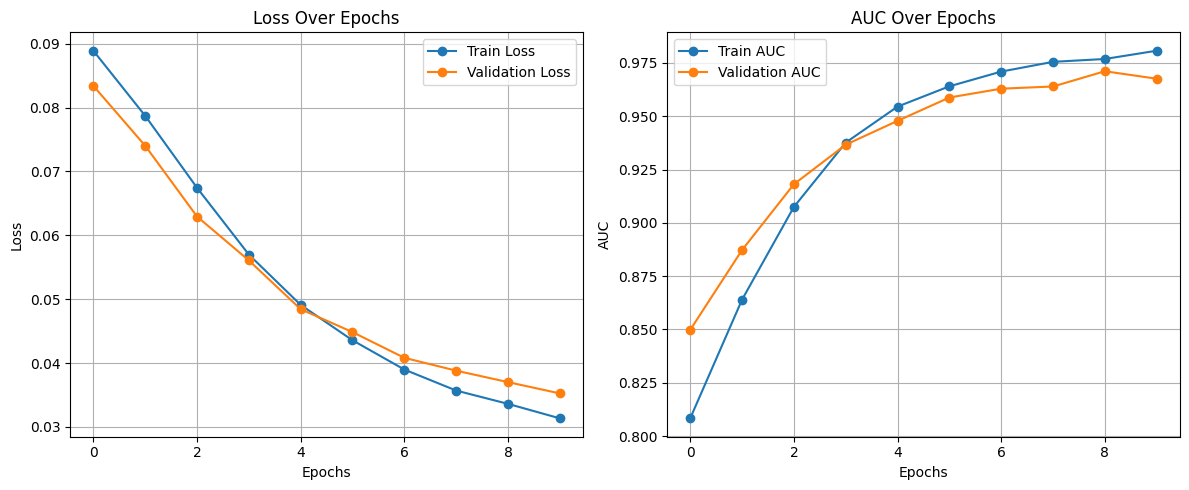

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training & validation AUC
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC', marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', marker='o')
plt.title('AUC Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_auc = history.history['auc'][-1]
val_auc = history.history['val_auc'][-1]

print(f"Final Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Final Training AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")

Final Training Loss: 0.0313, Validation Loss: 0.0352
Final Training AUC: 0.9807, Validation AUC: 0.9676


In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# y_test = true labels, y_pred = model predictions (threshold 0.5 for binary)
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed report
print(classification_report(y_test, y_pred))

4532/4532 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Confusion Matrix:
 [[141452    451]
 [  1224   1884]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    141903
           1       0.81      0.61      0.69      3108

    accuracy                           0.99    145011
   macro avg       0.90      0.80      0.84    145011
weighted avg       0.99      0.99      0.99    145011



4532/4532 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


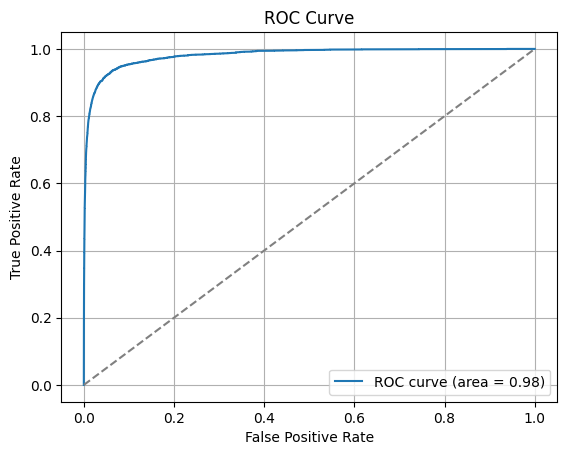

In [11]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Suppose X_train, y_train are your current training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_final)}, Validation samples: {len(X_val)}")

Training samples: 464034, Validation samples: 116009


In [13]:
X = df.drop(columns=['SepsisLabel', 'Patient_ID']).values
y = df['SepsisLabel'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# Now split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

X shape: (1048575, 42)
y shape: (1048575,)
Train: (838860, 42) (838860,)
Validation: (209715, 42) (209715,)


In [14]:
timesteps = 12   # sequence length
features = 41

# Convert flat data into sequences
X_seq = []
y_seq = []

for pid, group in df.groupby("Patient_ID"):
    values = group.drop(columns=['SepsisLabel', 'Patient_ID']).values
    labels = group['SepsisLabel'].values
    
    for i in range(len(values) - timesteps + 1):
        X_seq.append(values[i:i+timesteps])
        y_seq.append(labels[i+timesteps-1])  # label = last timestep

X = np.array(X_seq)
y = np.array(y_seq)

print("Final X shape:", X.shape)  # (samples, timesteps, features)
print("Final y shape:", y.shape)


Final X shape: (751507, 12, 42)
Final y shape: (751507,)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (601205, 12, 42) (601205,)
Validation: (150302, 12, 42) (150302,)


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_auc' if you want
    patience=3,           # stop if no improvement for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,            # large max
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 59s 12ms/step - accuracy: 0.9892 - auc: 0.9783 - loss: 0.0306 - val_accuracy: 0.9913 - val_auc: 0.9854 - val_loss: 0.0248
Epoch 2/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - accuracy: 0.9907 - auc: 0.9818 - loss: 0.0271 - val_accuracy: 0.9912 - val_auc: 0.9825 - val_loss: 0.0247
Epoch 3/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 59s 13ms/step - accuracy: 0.9912 - auc: 0.9847 - loss: 0.0250 - val_accuracy: 0.9920 - val_auc: 0.9867 - val_loss: 0.0230
Epoch 4/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 147s 31ms/step - accuracy: 0.9917 - auc: 0.9852 - loss: 0.0237 - val_accuracy: 0.9921 - val_auc: 0.9868 - val_loss: 0.0229
Epoch 5/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 211s 45ms/step - accuracy: 0.9919 - auc: 0.9887 - loss: 0.0225 - val_accuracy: 0.9924 - val_auc: 0.9885 - val_loss: 0.0218
Epoch 6/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 116s 25ms/step - accuracy: 0.9926 - auc: 0.9884 - loss: 0.0211 - val_accuracy: 0.9923 - val_auc: 0.9851 - val_loss: 0.0218
Epoch 7

In [17]:
model.save("bigru_sepsis_best.h5")

In [18]:
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9943 - auc: 0.9859 - loss: 0.0178
Validation Loss: 0.0173, Accuracy: 0.9943, AUC: 0.9874


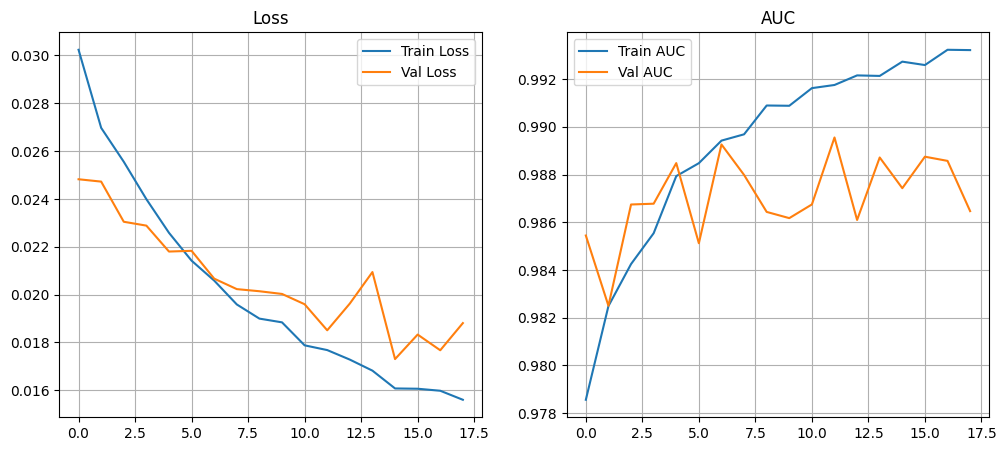

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend(); plt.grid(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label="Train AUC")
plt.plot(history.history['val_auc'], label="Val AUC")
plt.legend(); plt.grid(); plt.title("AUC")

plt.show()

In [23]:
y_pred = (model.predict(X_val) > 0.5).astype(int)

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [24]:
from sklearn.metrics import classification_report

y_val_pred = (model.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, y_val_pred))

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    147118
           1       0.87      0.87      0.87      3184

    accuracy                           0.99    150302
   macro avg       0.93      0.93      0.93    150302
weighted avg       0.99      0.99      0.99    150302



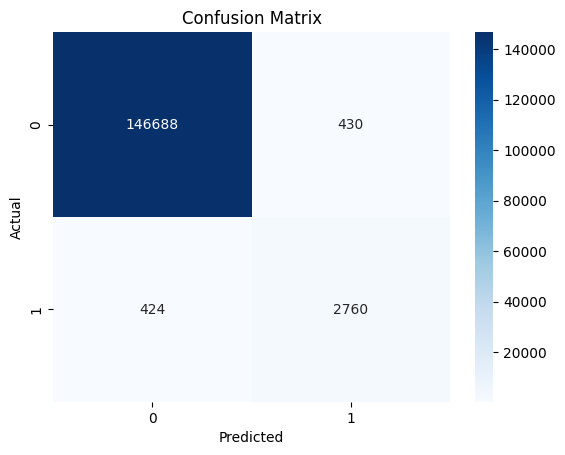

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
Validation AUC: 0.9945


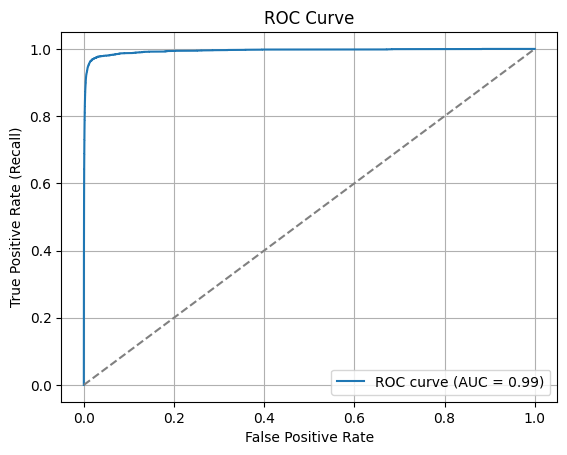

Best threshold: 0.019

Classification report at best threshold:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    147118
           1       0.53      0.97      0.68      3184

    accuracy                           0.98    150302
   macro avg       0.76      0.98      0.84    150302
weighted avg       0.99      0.98      0.98    150302



In [26]:
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predicted probabilities for validation set
y_val_prob = model.predict(X_val)  # values between 0 and 1

# 2. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)
print(f"Validation AUC: {roc_auc:.4f}")

# 3. Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Find the best threshold
# Method: maximize (Recall - False Positive Rate) → Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.3f}")

# 5. Evaluate metrics at this threshold
y_val_pred_best = (y_val_prob >= best_threshold).astype(int)
print("\nClassification report at best threshold:")
print(classification_report(y_val, y_val_pred_best))

In [27]:
model.save("sepsis_bigru_model.h5")

# Save the best threshold
import json
best_threshold = 0.013
with open("best_threshold.json", "w") as f:
    json.dump({"threshold": best_threshold}, f)

In [28]:
from tensorflow.keras.models import load_model
import json

# Load model
model = load_model("sepsis_bigru_model.h5")

# Load threshold
with open("best_threshold.json", "r") as f:
    best_threshold = json.load(f)["threshold"]

In [29]:
print("Loaded threshold:", best_threshold)


Loaded threshold: 0.013


In [30]:
X_test_preprocessed = X_test  # replace with actual preprocessed test data
y_test_true = y_test  
y_prob = model.predict(X_test_preprocessed)

# Apply threshold
y_pred = (y_prob >= best_threshold).astype(int)

4532/4532 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    141903
           1       0.50      0.97      0.66      3108

    accuracy                           0.98    145011
   macro avg       0.75      0.98      0.83    145011
weighted avg       0.99      0.98      0.98    145011

Confusion Matrix:
[[138884   3019]
 [    82   3026]]


In [32]:
from tensorflow.keras.models import load_model
import numpy as np
import json

# --- Load model & threshold ---
model = load_model("sepsis_bigru_model.h5")
with open("best_threshold.json", "r") as f:
    best_threshold = json.load(f)["threshold"]
print("Using threshold:", best_threshold)

# --- Your sequence here (12 x 41) ---
new_patient_sequence = [
    [80, 98, 36.7, 120, 80, 93, 18, 35, 1, 24, 0.21, 7.40, 40, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [82, 97, 36.8, 118, 78, 92, 19, 36, 0, 23, 0.22, 7.39, 42, 97, 24, 1, 11, 13, 0.5, 2.1, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 97, 36.7, 119, 79, 92, 18, 35, 0, 23, 0.21, 7.40, 41, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [79, 96, 36.6, 117, 77, 91, 17, 34, 0, 23, 0.21, 7.39, 39, 96, 23, 1, 9, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [78, 97, 36.7, 118, 78, 92, 18, 35, 0, 23, 0.21, 7.39, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 98, 36.8, 119, 79, 93, 18, 35, 1, 24, 0.21, 7.40, 41, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.39, 42, 97, 24, 1, 11, 13, 0.5, 2.1, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [82, 96, 36.6, 117, 77, 91, 17, 35, 0, 23, 0.21, 7.39, 41, 96, 23, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.40, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [79, 96, 36.6, 117, 77, 91, 17, 35, 0, 23, 0.21, 7.39, 39, 96, 23, 1, 9, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.40, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 98, 36.8, 119, 79, 93, 18, 35, 1, 24, 0.21, 7.40, 41, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# --- Make numpy array, float32 ---
seq = np.array(new_patient_sequence, dtype=np.float32)

# --- Inspect expected input shape ---
# model.input_shape is typically (None, timesteps, features)
inp_shape = model.input_shape
T_expected = inp_shape[1]  # can be None (variable length) or a fixed int
F_expected = inp_shape[2]

print(f"Model expects: timesteps={T_expected}, features={F_expected}")
print(f"Given: timesteps={seq.shape[0]}, features={seq.shape[1]}")

# --- Fix timesteps if model was built with a fixed length ---
if T_expected is not None:
    if seq.shape[0] > T_expected:
        # keep the most recent T_expected hours
        seq = seq[-T_expected:, :]
    elif seq.shape[0] < T_expected:
        # pad at the front with zeros (or your training-time pad value)
        pad = np.zeros((T_expected - seq.shape[0], seq.shape[1]), dtype=np.float32)
        seq = np.vstack([pad, seq])

# --- Fix feature count to match the model ---
F_actual = seq.shape[1]
if F_actual > F_expected:
    # Trim extra columns (ideally, map using the exact training feature order)
    seq = seq[:, :F_expected]
elif F_actual < F_expected:
    # Pad missing columns with zeros (or training-time defaults)
    padf = np.zeros((seq.shape[0], F_expected - F_actual), dtype=np.float32)
    seq = np.hstack([seq, padf])

# Final batch shape: (1, T, F)
new_patient = seq[np.newaxis, :, :]

# --- Predict ---
y_prob = model.predict(new_patient)
y_pred = (y_prob >= best_threshold).astype(int)

status = "✅ Sepsis Detected" if y_pred[0][0] == 1 else "❌ No Sepsis Detected"
print("Sepsis Prediction:", status)
print("Predicted probability of sepsis:", float(y_prob[0][0]))


Using threshold: 0.013
Model expects: timesteps=12, features=42
Given: timesteps=12, features=41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Sepsis Prediction: ✅ Sepsis Detected
Predicted probability of sepsis: 0.954373300075531


Best Threshold (Youden J): 0.0193


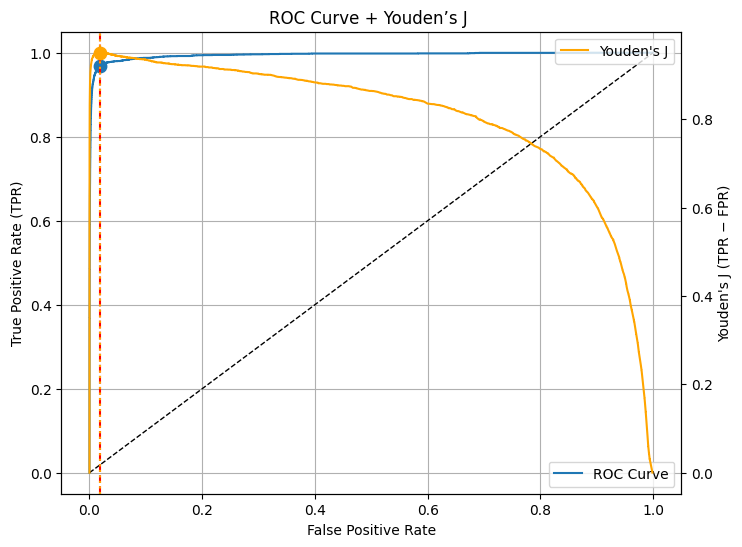

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Compute Youden’s J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (Youden J): {best_threshold:.4f}")

# Create the combined plot
fig, ax1 = plt.subplots(figsize=(8,6))

# ------------------ ROC Curve ------------------
ax1.plot(fpr, tpr, label="ROC Curve")
ax1.plot([0,1], [0,1], 'k--', linewidth=1)
ax1.scatter(fpr[best_idx], tpr[best_idx], s=80)

ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (TPR)")
ax1.set_title("ROC Curve + Youden’s J ")
ax1.grid(True)

# ------------------ J Statistic Curve (2nd axis) ------------------
ax2 = ax1.twinx()
ax2.plot(thresholds, j_scores, color='orange', label="Youden's J")
ax2.scatter(best_threshold, j_scores[best_idx], color='orange', s=80)
ax2.set_ylabel("Youden's J (TPR − FPR)")

# ------------------ Best Threshold Vertical Line ------------------
ax1.axvline(fpr[best_idx], color='red', linestyle='--')
ax2.axvline(best_threshold, color='orange', linestyle=':')

# ------------------ Legends ------------------
ax1.legend(loc="lower right")
ax2.legend(loc="upper right")

plt.show()


Best Threshold: 0.019314615
AUC: 0.9945233942384197


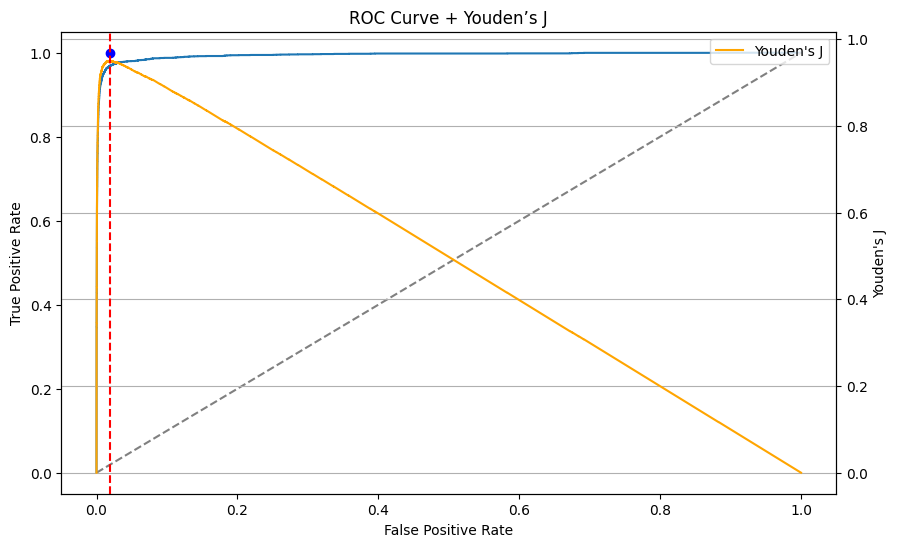

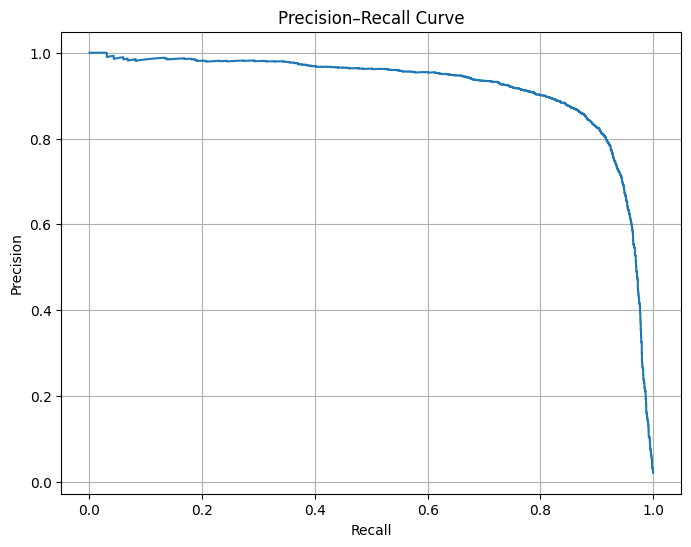

c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


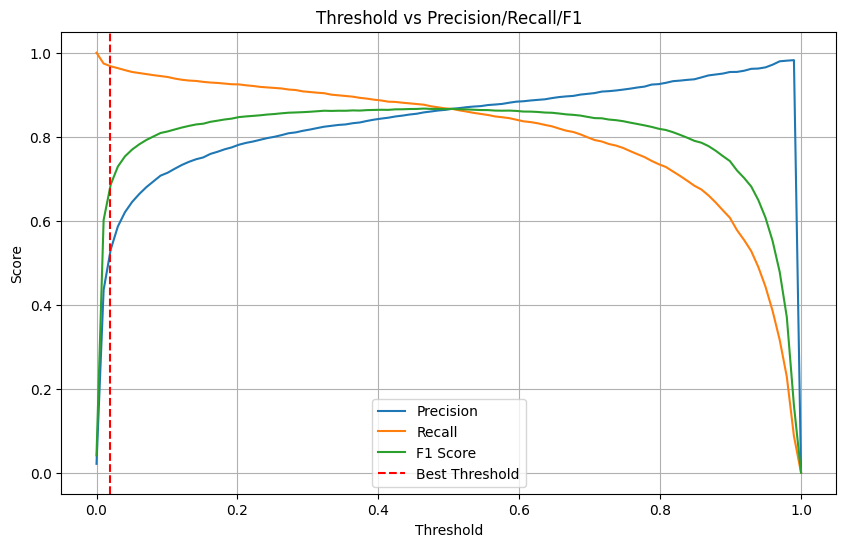

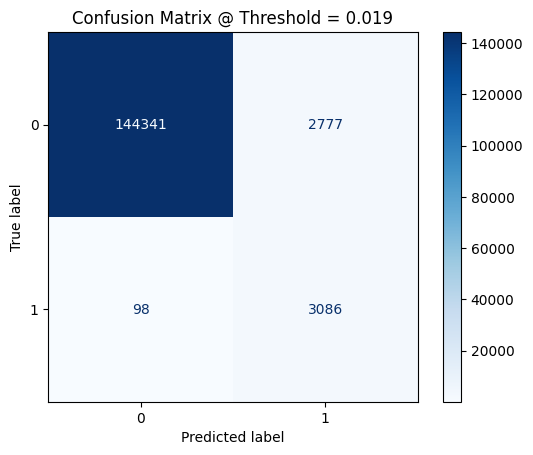

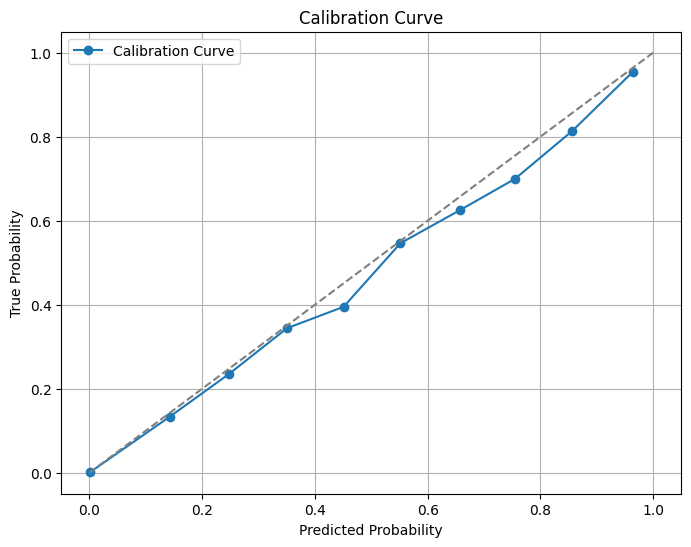

ValueError: operands could not be broadcast together with shapes (3184,) (147118,) 

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

# -------------------------------
# 1. Compute core metrics
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

# Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

y_pred_best = (y_val_prob >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print("AUC:", roc_auc_score(y_val, y_val_prob))

# ---------------------------------------------------
# 2. PLOT 1 — ROC + Youden’s J Combined Visualization
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Youden's J curve (secondary axis)
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(fpr, j_scores, color="orange", label="Youden's J")

# mark best threshold
plt.axvline(fpr[best_idx], color="red", linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], color="blue")

ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax2.set_ylabel("Youden's J")
plt.title("ROC Curve + Youden’s J")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------
# 3. PLOT 2 — Precision–Recall Curve
# ---------------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_val_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# 4. PLOT 3 — Threshold vs Precision, Recall, F1 Score
# -----------------------------------------------------
thresholds_plot = np.linspace(0, 1, 100)
prec_list, rec_list, f1_list = [], [], []

for th in thresholds_plot:
    y_pred = (y_val_prob >= th).astype(int)
    prec_list.append(precision_score(y_val, y_pred))
    rec_list.append(recall_score(y_val, y_pred))
    f1_list.append(f1_score(y_val, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(thresholds_plot, prec_list, label="Precision")
plt.plot(thresholds_plot, rec_list, label="Recall")
plt.plot(thresholds_plot, f1_list, label="F1 Score")
plt.axvline(best_threshold, color="red", linestyle="--", label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall/F1")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------
# 5. PLOT 4 — Confusion Matrix at Best Threshold
# --------------------------------------------
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix @ Threshold = {best_threshold:.3f}")
plt.show()

# ----------------------------
# 6. PLOT 5 — Calibration Curve
# ----------------------------
prob_true, prob_pred = calibration_curve(y_val, y_val_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label="Calibration Curve")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# 7. PLOT 6 — KS Statistic
# -------------------------
cdf_sepsis = np.cumsum(y_val_prob[y_val == 1]) / np.sum(y_val_prob[y_val == 1])
cdf_nonsepsis = np.cumsum(y_val_prob[y_val == 0]) / np.sum(y_val_prob[y_val == 0])

ks_statistic = np.max(np.abs(cdf_sepsis - cdf_nonsepsis))
print("KS Statistic:", ks_statistic)

plt.figure(figsize=(8, 6))
plt.plot(cdf_sepsis, label="Sepsis CDF")
plt.plot(cdf_nonsepsis, label="Non-Sepsis CDF")
plt.title(f"KS Curve (KS = {ks_statistic:.3f})")
plt.xlabel("Sorted Probabilities")
plt.ylabel("Cumulative Distribution")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------------------
# 8. PLOT 7 — Probability Distribution Plots
# -------------------------------------------
plt.figure(figsize=(8, 6))
plt.hist(y_val_prob[y_val == 1], bins=30, alpha=0.6, label="Sepsis")
plt.hist(y_val_prob[y_val == 0], bins=30, alpha=0.6, label="Non-Sepsis")
plt.axvline(best_threshold, color="red", linestyle="--", label="Best Threshold")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution of Predictions")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# # %% K-FOLD VALIDATION (put this after you define df0 and feature_cols)
# import warnings
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import GroupKFold
# from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, classification_report, confusion_matrix

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping

# RANDOM_SEED = 42
# np.random.seed(RANDOM_SEED)
# tf.random.set_seed(RANDOM_SEED)

# # Ensure required columns
# df0 = df.copy()  # use your already-loaded & cleaned dataframe variable
# assert {"Patient_ID","Hour","SepsisLabel"}.issubset(df0.columns)

# # --- Helpers ---
# def preprocess_fit_transform(train_df, feature_cols):
#     train_df = train_df.sort_values(["Patient_ID","Hour"]).copy()
#     train_df[feature_cols] = (train_df.groupby("Patient_ID", group_keys=False)[feature_cols]
#                                       .ffill()
#                                       .fillna(0))
#     scaler = StandardScaler()
#     train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols].values)
#     return train_df, scaler

# def preprocess_transform(test_df, feature_cols, scaler):
#     test_df = test_df.sort_values(["Patient_ID","Hour"]).copy()
#     test_df[feature_cols] = (test_df.groupby("Patient_ID", group_keys=False)[feature_cols]
#                                     .ffill()
#                                     .fillna(0))
#     test_df[feature_cols] = scaler.transform(test_df[feature_cols].values)
#     return test_df

# def make_sequences(df_in, feature_cols, timesteps=12):
#     X_list, y_list = [], []
#     for pid, grp in df_in.groupby("Patient_ID"):
#         v = grp[feature_cols].values
#         y = grp["SepsisLabel"].values
#         if len(v) < timesteps:
#             continue
#         for i in range(len(v) - timesteps + 1):
#             X_list.append(v[i:i+timesteps])
#             y_list.append(y[i+timesteps-1])  # last-step label
#     if not X_list:
#         return np.empty((0, timesteps, len(feature_cols))), np.empty((0,))
#     return np.stack(X_list), np.array(y_list)

# def build_model(timesteps, n_features):
#     model = Sequential([
#         Bidirectional(GRU(64, return_sequences=True), input_shape=(timesteps, n_features)),
#         Dropout(0.3),
#         Bidirectional(GRU(32)),
#         Dropout(0.3),
#         Dense(1, activation="sigmoid")
#     ])
#     model.compile(optimizer="adam", loss="binary_crossentropy",
#                   metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
#     return model

# # --- Patient-level groups + (optional) stratification by patient outcome ---
# # one label per patient: whether they ever had sepsis
# patient_has_sepsis = df0.groupby("Patient_ID")["SepsisLabel"].max()
# pid2label = patient_has_sepsis.to_dict()
# groups = df0["Patient_ID"].values
# strata = df0["Patient_ID"].map(pid2label).values  # for SGKF if available

# # Splitter
# try:
#     from sklearn.model_selection import StratifiedGroupKFold
#     sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
#     splitter = sgkf.split(X=df0[["Patient_ID"]], y=strata, groups=groups)
# except Exception:
#     warnings.warn("StratifiedGroupKFold unavailable; using GroupKFold (no stratification).")
#     gkf = GroupKFold(n_splits=5)
#     splitter = gkf.split(X=df0[["Patient_ID"]], y=strata, groups=groups)

# # --- K-fold loop ---
# timesteps = 12
# fold_metrics = []
# all_val_probs, all_val_labels = [], []

# for fold, (tr_idx, va_idx) in enumerate(splitter, start=1):
#     tr_df = df0.iloc[tr_idx].copy()
#     va_df = df0.iloc[va_idx].copy()

#     # fit scaler on TRAIN only; transform both
#     tr_df_pp, scaler = preprocess_fit_transform(tr_df, feature_cols)
#     va_df_pp = preprocess_transform(va_df, feature_cols, scaler)

#     # sequences
#     X_tr, y_tr = make_sequences(tr_df_pp, feature_cols, timesteps=timesteps)
#     X_va, y_va = make_sequences(va_df_pp, feature_cols, timesteps=timesteps)
#     if len(X_tr) == 0 or len(X_va) == 0:
#         warnings.warn(f"Fold {fold}: insufficient sequence data; skipping.")
#         continue

#     # simple class weights
#     pos = y_tr.sum()
#     neg = len(y_tr) - pos
#     if pos == 0 or neg == 0:
#         class_weight = None
#     else:
#         w0 = (1.0 / (2.0 * neg))
#         w1 = (1.0 / (2.0 * pos))
#         scale = 1.0 / min(w0, w1)
#         class_weight = {0: w0*scale, 1: w1*scale}

#     model = build_model(timesteps, X_tr.shape[2])
#     es = EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)

#     model.fit(
#         X_tr, y_tr,
#         validation_data=(X_va, y_va),
#         epochs=100,
#         batch_size=128,
#         callbacks=[es],
#         verbose=0,
#         class_weight=class_weight
#     )

#     # fold eval
#     p_va = model.predict(X_va, verbose=0).ravel()
#     yhat05 = (p_va >= 0.5).astype(int)

#     from sklearn.metrics import roc_curve
#     auc_va = roc_auc_score(y_va, p_va) if len(np.unique(y_va)) > 1 else np.nan
#     acc_va = accuracy_score(y_va, yhat05)
#     f1_va  = f1_score(y_va, yhat05, zero_division=0)

#     fpr, tpr, thr = roc_curve(y_va, p_va)
#     j = tpr - fpr
#     best_thr = thr[np.argmax(j)]
#     f1_best = f1_score(y_va, (p_va >= best_thr).astype(int), zero_division=0)

#     fold_metrics.append({
#         "fold": fold, "AUC": float(auc_va),
#         "Acc@0.5": float(acc_va), "F1@0.5": float(f1_va),
#         "BestThr": float(best_thr), "F1@BestThr": float(f1_best),
#         "PosRate(val)": float(y_va.mean())
#     })
#     all_val_probs.append(p_va); all_val_labels.append(y_va)

#     print(f"[Fold {fold}] AUC={auc_va:.4f} Acc@0.5={acc_va:.4f} F1@0.5={f1_va:.4f} BestThr={best_thr:.4f} F1@Best={f1_best:.4f}")

# # aggregate
# metrics_df = pd.DataFrame(fold_metrics)
# print("\nPer-fold metrics:\n", metrics_df)
# print("\nMean metrics:\n", metrics_df[["AUC","Acc@0.5","F1@0.5","F1@BestThr"]].mean().round(4))

# # Global OOF threshold
# y_all = np.concatenate(all_val_labels)
# p_all = np.concatenate(all_val_probs)
# from sklearn.metrics import roc_curve, roc_auc_score
# fpr_all, tpr_all, thr_all = roc_curve(y_all, p_all)
# best_thr_all = thr_all[np.argmax(tpr_all - fpr_all)]
# print(f"\nGlobal OOF AUC={roc_auc_score(y_all, p_all):.4f} | Global best threshold={best_thr_all:.4f}")

# # Save threshold for deployment
# import json
# with open("best_threshold.json","w") as f:
#     json.dump({"threshold": float(best_thr_all)}, f)
# print("Saved global best threshold -> best_threshold.json")

# # (Optional) Retrain on ALL data afterwards to save a final model for inference
# # Here we just save the last trained model:
# model.save("sepsis_bigru_model.h5")


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Fold 1] AUC=0.8170 Acc@0.5=0.7525 F1@0.5=0.1087 BestThr=0.5122 F1@Best=0.1107


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Fold 2] AUC=0.8128 Acc@0.5=0.7546 F1@0.5=0.1136 BestThr=0.4152 F1@Best=0.1038


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 